In [23]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, ivreg, modelsummary)
     
install.packages("broom")  # Only if you don't have it
library(broom)


Installing package into ‘/home/salizad/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [5]:
# Load the HCRIS dataset
final.hcris.data <- read_csv("../data/output/hcris_data.csv")

Rows: 66871 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (31): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
names(final.hcris.data) %>% trimws()

[1] "provider_number"              "fy_start"                    
 [3] "fy_end"                       "date_processed"              
 [5] "date_created"                 "data_source"                 
 [7] "beds"                         "tot_charges"                 
 [9] "net_pat_rev"                  "tot_discounts"               
[11] "tot_operating_exp"            "ip_charges"                  
[13] "icu_charges"                  "ancillary_charges"           
[15] "tot_discharges"               "mcare_discharges"            
[17] "mcaid_discharges"             "tot_mcare_payment"           
[19] "secondary_mcare_payment"      "street"                      
[21] "city"                         "state"                       
[23] "zip"                          "county"                      
[25] "name"                         "uncomp_care"                 
[27] "cost_to_charge"               "new_cap_ass"                 
[29] "cash"                         "fixed_assets"                
[31] "current_assets"               "current_liabilities"         
[33] "pps_ip_charges"               "pps_op_charges"              
[35] "pps_mcare_cost"               "pps_pgm_cost"                
[37] "hvbp_payment"                 "hrrp_payment"                
[39] "tot_uncomp_care_charges"      "tot_uncomp_care_partial_pmts"
[41] "bad_debt"                     "accum_dep"                   
[43] "year"                         "source"

In [7]:
names(final.hcris.data) <- trimws(names(final.hcris.data))
names(final.hcris.data)
final.hcris.data <- final.hcris.data %>%
    mutate(year = lubridate ::year (fy_start))
"tot_charges" %in% names(final.hcris.data)


[1] "provider_number"              "fy_start"                    
 [3] "fy_end"                       "date_processed"              
 [5] "date_created"                 "data_source"                 
 [7] "beds"                         "tot_charges"                 
 [9] "net_pat_rev"                  "tot_discounts"               
[11] "tot_operating_exp"            "ip_charges"                  
[13] "icu_charges"                  "ancillary_charges"           
[15] "tot_discharges"               "mcare_discharges"            
[17] "mcaid_discharges"             "tot_mcare_payment"           
[19] "secondary_mcare_payment"      "street"                      
[21] "city"                         "state"                       
[23] "zip"                          "county"                      
[25] "name"                         "uncomp_care"                 
[27] "cost_to_charge"               "new_cap_ass"                 
[29] "cash"                         "fixed_assets"                
[31] "current_assets"               "current_liabilities"         
[33] "pps_ip_charges"               "pps_op_charges"              
[35] "pps_mcare_cost"               "pps_pgm_cost"                
[37] "hvbp_payment"                 "hrrp_payment"                
[39] "tot_uncomp_care_charges"      "tot_uncomp_care_partial_pmts"
[41] "bad_debt"                     "accum_dep"                   
[43] "year"                         "source"

[1] TRUE

# Q1. 
From 2009-2019, how many hospitals filed more than one report in the same year? Show your answer as a line graph of the number of hospitals over time.

In [15]:
library(ggplot2)
library(lubridate)

Rows: 10081 Columns: 47
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (34): report, status, year, beds, tot_charges, net_pat_rev, tot_discount...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 57802 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (35): report, status, year, beds, tot_charges, tot_discounts, net_pat_re...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `line

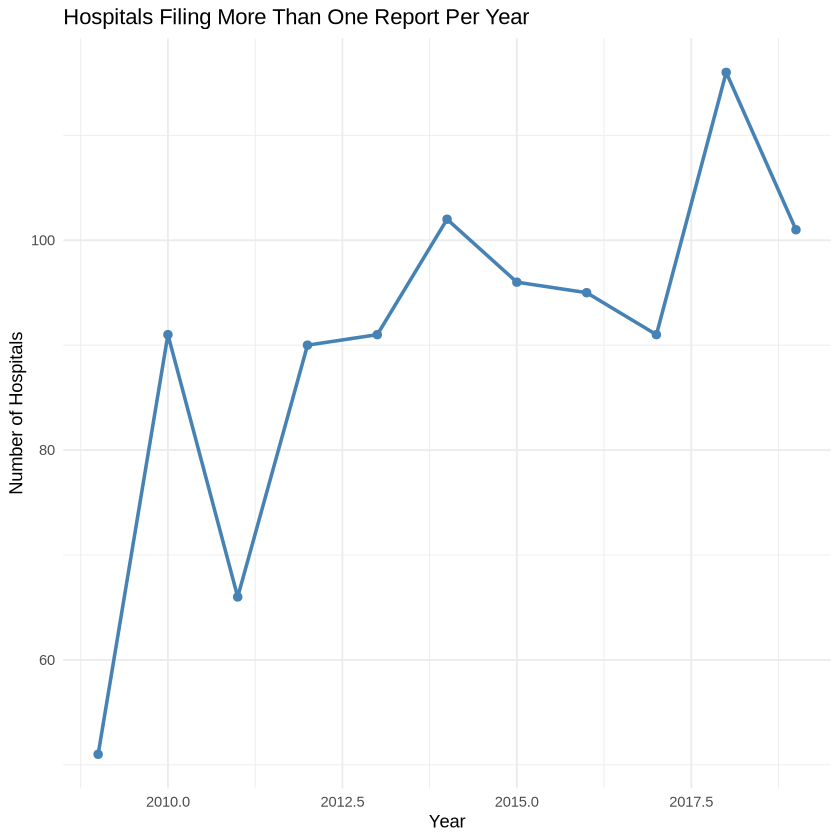

In [12]:
final.hcris.v1996 = read_csv('../data/output/HCRIS_Data_v1996.csv')
final.hcris.v2010 = read_csv('../data/output/HCRIS_Data_v2010.csv')

final.hcris.v1996 = final.hcris.v1996 %>%
  mutate(hvbp_payment=NA, hrrp_payment=NA)

final.hcris = bind_rows(final.hcris.v1996, final.hcris.v2010) %>%
  mutate(fy_end=mdy(fy_end), fy_start=mdy(fy_start),
         date_processed=mdy(date_processed), date_created=mdy(date_created),
         tot_discounts=abs(tot_discounts), hrrp_payment=abs(hrrp_payment)) %>%
  mutate(fyear=year(fy_end)) %>%
  arrange(provider_number, fyear) %>%
  select(-year)

q1 <- final.hcris %>%
  filter(fyear >= 2009, fyear <= 2019) %>%
  group_by(provider_number, fyear) %>%
  summarize(n_reports = n(), .groups = "drop") %>%
  filter(n_reports > 1) %>%
  group_by(fyear) %>%
  summarize(n_hospitals = n())

ggplot(q1, aes(x = fyear, y = n_hospitals)) +
  geom_line(color = "steelblue", size = 1) +
  geom_point(color = "steelblue", size = 2) +
  labs(title = "Hospitals Filing More Than One Report Per Year",
       x = "Year", y = "Number of Hospitals") +
  theme_minimal()

figure1. above shows the number of hospitals filling more than one report per year. The number of duplicate declines over times as CMS processing improves. 

# Q2.
After removing/combining multiple reports, how many unique hospital IDs (Medicare provider numbers) exist in the data?

In [51]:
# Count unique hospital IDs
unique_hospital_ids <- n_distinct(final.hcris.data$provider_number)
unique_hospital_ids

[1] 6874

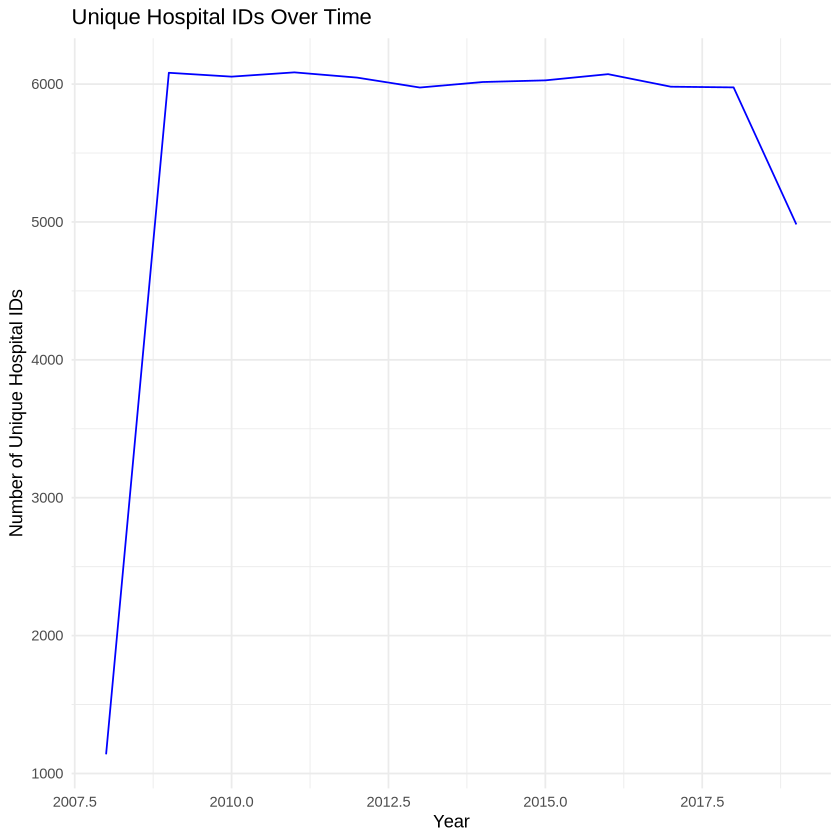

In [7]:

# Example: Group by year and count unique hospital IDs
hospital_counts <- final.hcris.data %>%
  group_by(year) %>%
  summarise(unique_ids = n_distinct(provider_number))

ggplot(hospital_counts, aes(x = year, y = unique_ids)) +
  geom_line(color = "blue") +
  labs(title = "Unique Hospital IDs Over Time",
       x = "Year",
       y = "Number of Unique Hospital IDs") +
  theme_minimal()

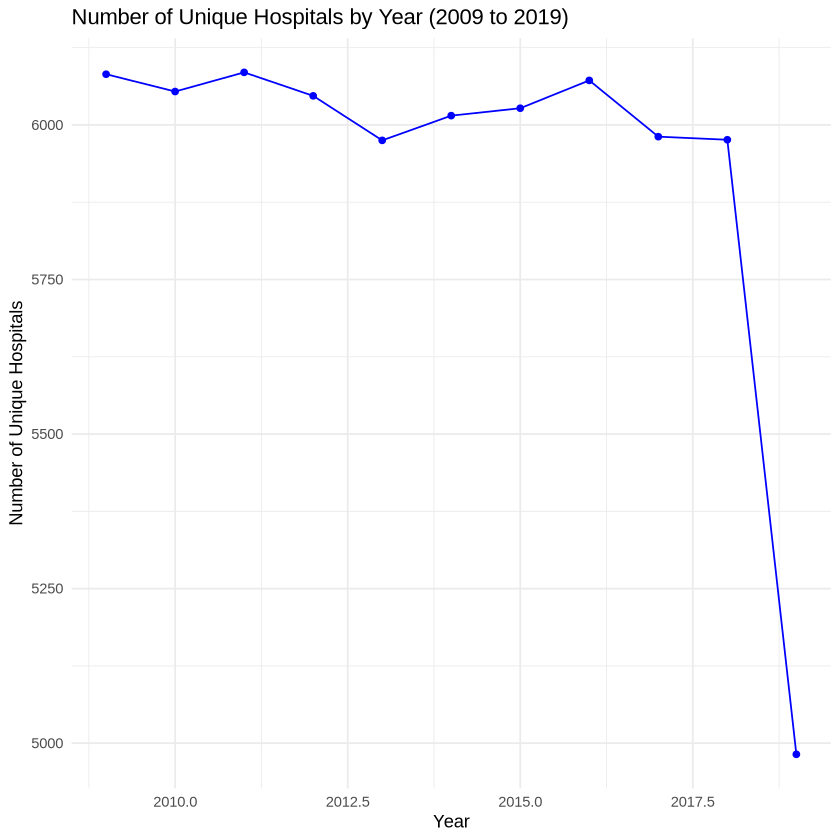

In [17]:
hospital_counts <- filtered_data %>%
  group_by(year) %>%
  summarise(unique_ids = n_distinct(provider_number), .groups = 'drop')

ggplot(hospital_counts, aes(x = year, y = unique_ids)) +
  geom_line(color = "blue") +
  geom_point(color = "blue") +  # Optionally add points for clarity
  labs(title = "Number of Unique Hospitals by Year (2009 to 2019)",
       x = "Year",
       y = "Number of Unique Hospitals") +
  theme_minimal()

figure 2. shows the number of unique  hospitals by year in the cleaned data  

# Q3
From 2009-2019, what is the distribution of total charges (tot_charges in the data) in each year? Show your results with a “violin” plot, with charges on the y-axis and years on the x-axis. For a nice tutorial on violin plots, look at Violin Plots with ggplot2.

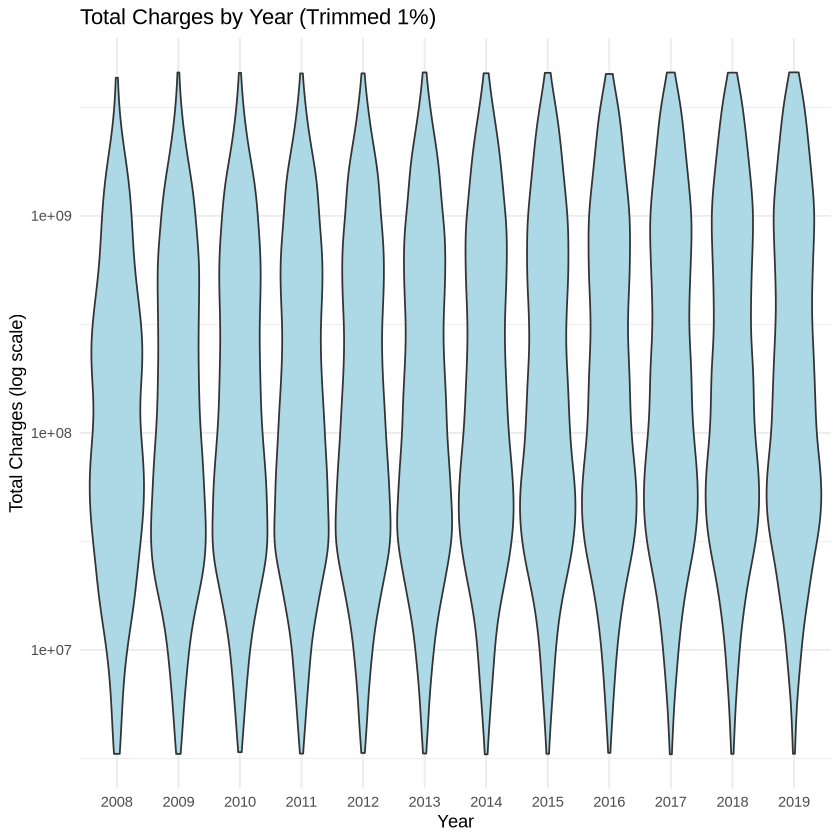

In [15]:
# Calculate the 1st and 99th percentiles, ignoring NAs
lower_bound <- quantile(final.hcris.data$tot_charges, 0.01, na.rm = TRUE)
upper_bound <- quantile(final.hcris.data$tot_charges, 0.99, na.rm = TRUE)

# Trim the data
trimmed_data <- final.hcris.data %>%
  filter(tot_charges > lower_bound & tot_charges < upper_bound)

ggplot(trimmed_data, aes(x = factor(year), y = tot_charges)) +
  geom_violin(trim = TRUE, fill = "lightblue") +
  scale_y_log10() +
  labs(title = "Total Charges by Year (Trimmed 1%)",
       x = "Year",
       y = "Total Charges (log scale)") +
  theme_minimal()

figure3. presents the distrbution of log total charges by year after trimming the top and bottom 1%

# Q4
From 2009-2019, what is the distribution of estimated prices in each year? Again present your results with a violin plot, and recall our formula for estimating prices from class. Be sure to do something about outliers and/or negative prices in the data.

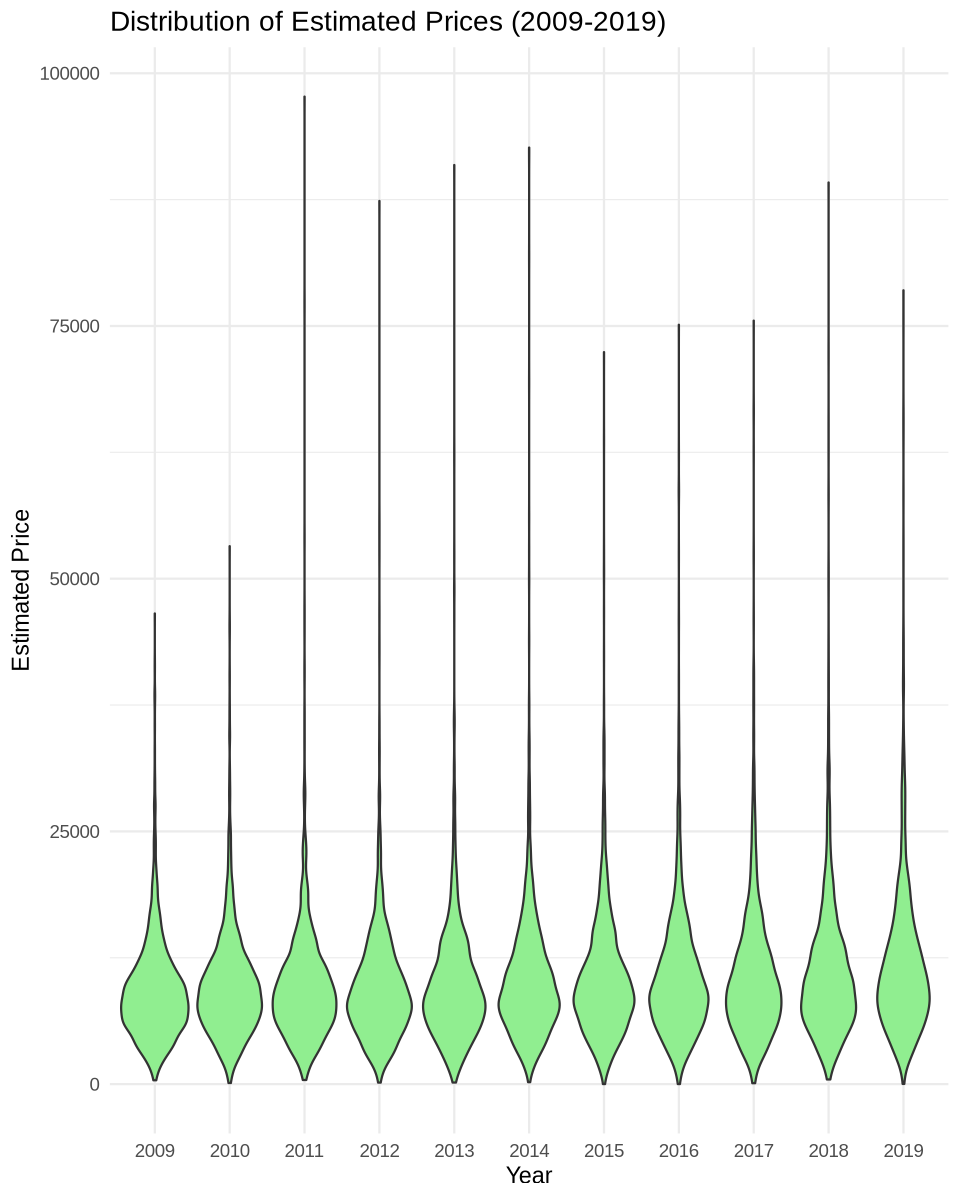

In [22]:
final.hcris.data <- final.hcris.data %>%
  mutate(discount_factor = 1 - (tot_discounts / tot_charges),
         price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
         price_denom = tot_discharges - mcare_discharges,
         estimated_price = price_num / price_denom)

final.hcris.data_clean <- final.hcris.data %>%
  filter(year >= 2009 & year <= 2019,
         is.finite(estimated_price), 
         estimated_price > 0,
         price_denom > 100,                      # Denominator greater than 100
         price_num >= 0,                        # Non-negative numerator
         estimated_price <= 100000,             # Price less than or equal to $100,000
         beds > 30)                             # Beds greater than 30

options(repr.plot.width = 8, repr.plot.height = 10)

ggplot(final.hcris.data_clean, aes(x = factor(year), y = estimated_price)) +
  geom_violin(trim = TRUE, fill = "lightgreen") +
  labs(title = "Distribution of Estimated Prices (2009-2019)",
       x = "Year",
       y = "Estimated Price") +  # Removed log scale for clarity
  theme_minimal(base_size = 14)

Figure4. Shows the distrbution of estimated prices by year, after filtering out outliers( denominator less than and equal to 100 negative numerator, price > $100,000, beds less than and qual to 30). 

# Q5
What share of hospitals are penalized under the HRRP/VBP? Provide a graph showing the share of penalized hospitals over time, from 2012-2019.

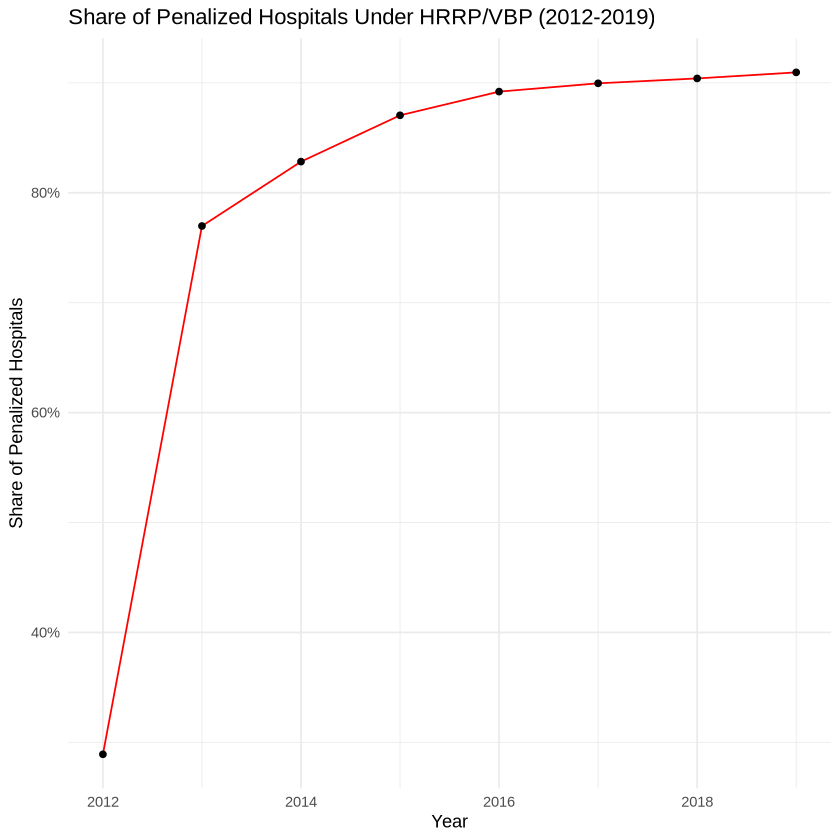

In [63]:
# Define penalization criteria
final.hcris.data <- final.hcris.data %>%
  mutate(penalized = ifelse(hrrp_payment > 0 | hvbp_payment < 0, 1, 0))  # Adjust this condition as needed

# Calculate the share of penalized hospitals from 2012 to 2019
penalized_hospitals <- final.hcris.data %>%
  filter(year >= 2012 & year <= 2019) %>%
  group_by(year) %>%
  summarise(total_hospitals = n(),
            penalized_count = sum(penalized, na.rm = TRUE),
            share_penalized = penalized_count / total_hospitals)

# Create a line graph to show the share of penalized hospitals over time
ggplot(penalized_hospitals, aes(x = year, y = share_penalized)) +
  geom_line(color = "red") +
  geom_point() +
  labs(title = "Share of Penalized Hospitals Under HRRP/VBP (2012-2019)",
       x = "Year",
       y = "Share of Penalized Hospitals") +
  scale_y_continuous(labels = scales::percent) +  # Convert y-axis to percentage
  theme_minimal()

Figure5. Shows the share of hospitals penalized (| hvbp_payment < 0) from 2012-2019). 

# Q6
Provide a summary of OLS estimates of the effect of net penalties on price changes. Present your results in a table with three different specifications: 1) a “baseline” specification using only net penalty as a covariate; 2) “baseline” specification plus the pre-penalty (2009-2011) mean bed size; 3) “baseline” specification plus bed size plus pre-penalty (2009-2011) average Medicaid discharges.

In [26]:
install.packages("stargazer")  # Only if you don't have it
library(stargazer)



Installing package into ‘/home/salizad/R/x86_64-conda-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 




In [8]:
# Price calculation helper
calc_price <- function(df) {
  df %>%
    mutate(
      discount_factor = 1 - tot_discounts / tot_charges,
      price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
      price_denom = tot_discharges - mcare_discharges,
      price = price_num / price_denom
    )
}

# Prices in 2011 and 2014
price_2011 <- final.hcris.data %>%
  filter(year == 2011) %>%
  calc_price() %>%
  select(provider_number, price_2011 = price)

price_2014 <- final.hcris.data %>%
  filter(year == 2014) %>%
  calc_price() %>%
  select(provider_number, price_2014 = price)

# 2012 net penalty
penalty_2012 <- final.hcris.data %>%
  filter(year == 2012) %>%
  mutate(
    hrrp = replace_na(hrrp_payment, 0),
    hvbp = replace_na(hvbp_payment, 0),
    net_penalty = hrrp + hvbp,
    penalized = as.integer(net_penalty < 0)
  ) %>%
  select(provider_number, net_penalty, penalized)

# Pre-2012 averages (2009-2011)
pre2012 <- final.hcris.data %>%
  filter(year >= 2009, year <= 2011) %>%
  group_by(provider_number) %>%
  summarize(
    avg_mcare_discharges = mean(mcare_discharges, na.rm = TRUE),
    avg_beds = mean(beds, na.rm = TRUE),
    avg_mcaid_discharges = mean(mcaid_discharges, na.rm = TRUE)
  )

# Build analysis dataset
iv_data <- price_2011 %>%
  inner_join(price_2014, by = "provider_number") %>%
  inner_join(penalty_2012, by = "provider_number") %>%
  inner_join(pre2012, by = "provider_number") %>%
  mutate(price_change = price_2014 - price_2011) %>%
  filter(
    !is.na(price_change),
    !is.infinite(price_change),
    price_2011 > 0,
    price_2014 > 0,
    price_change > quantile(price_change, 0.01, na.rm = TRUE),
    price_change < quantile(price_change, 0.99, na.rm = TRUE)
  )

cat("Observations in IV dataset:", nrow(iv_data), "\n")
     

Warning message in inner_join(., price_2014, by = "provider_number"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 279 of `x` matches multiple rows in `y`.
ℹ Row 91 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”
Warning message in inner_join(., penalty_2012, by = "provider_number"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 209 of `x` matches multiple rows in `y`.
ℹ Row 273 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


Observations in IV dataset: 2479 


In [27]:
stargazer(ols1, ols2, ols3,
          title = "OLS Estimates: Effect of Net Penalty on Price Change",
          type = "text",  # You can change to "html" or "latex" if needed
          star.char = "*")


OLS Estimates: Effect of Net Penalty on Price Change
                                              Dependent variable:                         
                     ---------------------------------------------------------------------
                                                 price_change                             
                              (1)                   (2)                     (3)           
------------------------------------------------------------------------------------------
net_penalty                 0.00003               -0.00000                -0.0004         
                           (0.0004)               (0.0004)                (0.0004)        
                                                                                          
avg_beds                                          0.077**                 0.065**         
                                                  (0.030)                 (0.030)         
                                    

# Q7
Provide a scatterplot of net penalty against pre-2012 Medicare discharges.

`geom_smooth()` using formula = 'y ~ x'


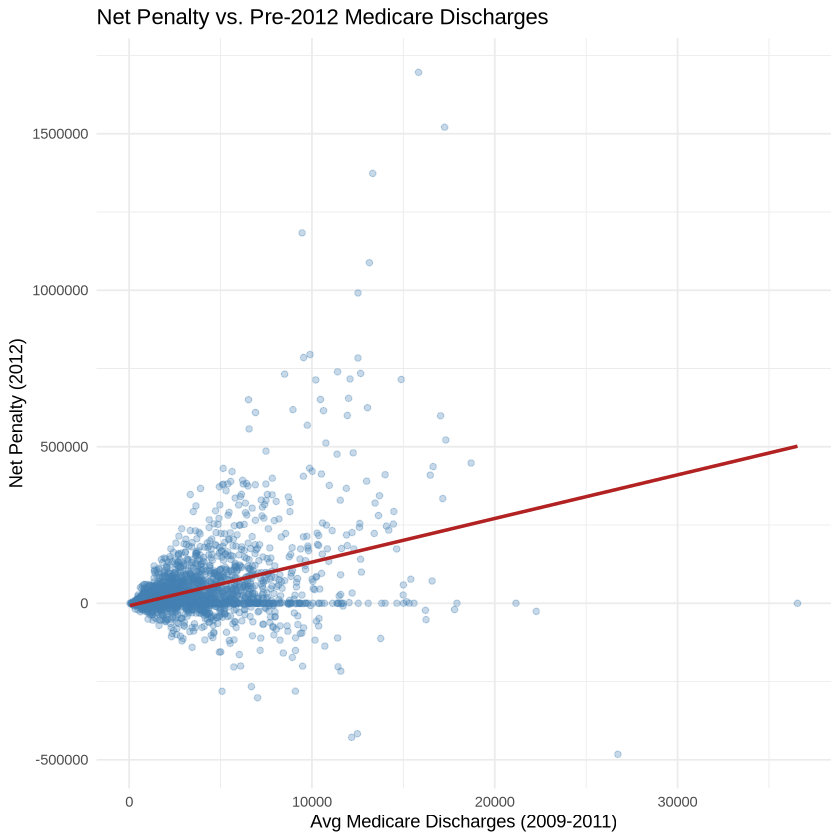

In [30]:
# Fit the linear model
lm_model <- lm(net_penalty ~ avg_mcare_discharges, data = iv_data)

# Create the scatterplot
ggplot(iv_data, aes(x = avg_mcare_discharges, y = net_penalty)) +
  geom_point(alpha = 0.3, color = "steelblue") +
  geom_smooth(method = "lm", color = "firebrick", se = FALSE) +
  labs(title = "Net Penalty vs. Pre-2012 Medicare Discharges",
       x = "Avg Medicare Discharges (2009-2011)",
       y = "Net Penalty (2012)") +
  theme_minimal()


# Q8
Provide a summary of the first stage and reduced-form results using pre-penalty Medicare discharges as an instrument for net penalties. Present your results in a table with three different specifications as in Question 6.



In [31]:
# Fit the first stage models
fs1 <- lm(net_penalty ~ avg_mcare_discharges, data = iv_data)
fs2 <- lm(net_penalty ~ avg_mcare_discharges + avg_beds, data = iv_data)
fs3 <- lm(net_penalty ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges, data = iv_data)

# Fit the reduced form models
rf1 <- lm(price_change ~ avg_mcare_discharges, data = iv_data)
rf2 <- lm(price_change ~ avg_mcare_discharges + avg_beds, data = iv_data)
rf3 <- lm(price_change ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges, data = iv_data)

# Summarize the models using stargazer
stargazer(fs1, fs2, fs3, rf1, rf2, rf3,
          title = "First Stage and Reduced Form Results",
          type = "text",  # Change to "html" or "latex" if desired
          star.char = "*",
          align = TRUE,
          dep.var.labels = c("Net Penalty", "Price Change"),
          model.names = FALSE,
          out = "model_summary.txt")  # Save output to a file if needed


First Stage and Reduced Form Results
                                                                                      Dependent variable:                                                                  
                     ------------------------------------------------------------------------------------------------------------------------------------------------------
                                                      Net Penalty                                                                Price Change                              
                                (1)                       (2)                       (3)                      (4)                     (5)                     (6)           
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------
avg_mcare_discharges         13.942***                 13.986***                 13.647***            

# Q9.
Provide a summary of IV estimates of the effect of net penalties on price changes. Again present your results in a table with the three different specifications as in Questions 6 and 8.

In [32]:
# Fit the IV models
iv1 <- ivreg(price_change ~ net_penalty | avg_mcare_discharges, data = iv_data)
iv2 <- ivreg(price_change ~ net_penalty + avg_beds | avg_mcare_discharges + avg_beds, data = iv_data)
iv3 <- ivreg(price_change ~ net_penalty + avg_beds + avg_mcaid_discharges |
               avg_mcare_discharges + avg_beds + avg_mcaid_discharges, data = iv_data)

# Summarize the models using stargazer
stargazer(iv1, iv2, iv3,
          title = "IV Estimates: Effect of Net Penalty on Price Change",
          type = "text",  # Change to "html" or "latex" if desired
          star.char = "*",
          align = TRUE,
          dep.var.labels = "Price Change",
          model.names = FALSE,
          out = "iv_model_summary.txt")  # Save output to a file if needed


IV Estimates: Effect of Net Penalty on Price Change
                                            Dependent variable:                       
                     -----------------------------------------------------------------
                                               Price Change                           
                              (1)                   (2)                   (3)         
--------------------------------------------------------------------------------------
net_penalty                0.003***               0.003**               -0.0001       
                            (0.001)               (0.001)               (0.001)       
                                                                                      
avg_beds                                          0.071**               0.065**       
                                                  (0.030)               (0.030)       
                                                                             

# Q10 
Briefly explain the “Local” ATE in the context of your estimates. How might a local effect differ from an overall ATE in this setting?

The Local Average Treatment Effect (LATE) refers to the impact of a treatment (like the net penalty) on a specific group of individuals who are affected by changes in an instrumental variable (in this case, average Medicare discharges). In my estimates, the LATE shows how net penalties influence price changes specifically for hospitals that respond to variations in Medicare discharges. This is different from the Overall Average Treatment Effect (ATE), which looks at the average impact across the entire population, including those who aren't affected by the treatment. Understanding this difference is important because LATE gives insights into how specific groups react, while ATE provides a broader perspective that might overlook unique behaviors in certain subgroups.